# CCNLP CCA1 — Identifying Hindustani Proverbs: Literal vs. Culturally Intended Figurative Meaning

**Group 16** &nbsp;|&nbsp; Panel B &nbsp;|&nbsp; School of Computer Science & Engineering, MIT-WPU

| Member | PRN | Language Scope |
|---|---|---|
|  Sahish Nagulwar  |  1032233310  |  Marathi  |
| ** Ibrahim Ansari ** | ** 1032233145 ** | ** Hindi (this notebook) ** |
| Chayan Raj Bharati | 1032233134 | Assamese |

**Team problem statement:** *Develop a multilingual NLP framework that identifies Indian idioms and distinguishes their literal meaning from culturally intended figurative meaning across Indian languages, while modeling cultural context and linguistic variation.*

**Individual scope (Ibrahim Ansari):** Hindi proverbs and idiomatic sayings, using a book-derived corpus.

## Research Question
> RQ: Can a classifier learn to tell the literal rendering of a Hindustani proverb apart from its figurative explanation, and how well does lexical retrieval link a proverb to its own explanation when the query crosses from English to romanized Hindustani?

## Research Contribution
The main output of this work is a machine-readable corpus of 344 Hindustani proverbs taken from Fallon (1886). Each entry has the romanized text, a literal English translation and the dictionary's parenthesized gloss of the intended meaning (334 entries). The extraction uses the same pipeline as the other two tracks. Two experiments are run on the corpus: a classifier that tries to tell literal renderings apart from figurative glosses, which is a small version of the team problem statement, and retrieval of the correct gloss for a given proverb, with TF-IDF as the lexical method and LaBSE/MuRIL as the multilingual condition.

## Methodology
The corpus is built from the Internet Archive OCR of Fallon (1886). Romanized proverb lines are found by their low share of common English function words. The lines after them are taken as the literal translation, and the parenthesized note as the gloss. Entries that the OCR mangled too badly are dropped by an English-ratio filter. Two experiments follow. In the classification experiment, each proverb contributes two texts, its literal translation (class "literal") and its gloss (class "figurative"), and logistic regression over word TF-IDF is trained to tell them apart under stratified 5-fold CV. In the retrieval experiment, glosses are ranked by TF-IDF cosine for English-literal and for romanized-Hindustani queries over the 334 glossed entries, scored with P@k and MRR, and a LaBSE condition is included.


## 1. Corpus Description

**Source (book, public domain):** Fallon, S. W. (1886). *A Dictionary of Hindustani Proverbs.* Banaras: Medical Hall Press. Internet Archive: https://archive.org/details/in.ernet.dli.2015.42145

A dictionary of several thousand Hindustani proverbs and idioms, with Marwari, Panjabi, Maggah, Bhojpuri and Tirhuti variants. Each entry prints the proverb in native script, a romanized transliteration, a literal English translation, and a parenthesized note that states the intended sense or the situation the proverb is used in. The corpus was extracted with `PanelB_16_extract_hindi.py`. The raw OCR source is kept at `corpus/PanelB_16_hindi_fallon1886_raw.txt`. The dictionary is alphabetical and has no subject sections, so this track models the literal/figurative distinction itself instead of themes.

**Corpus size and why:** the dictionary runs to several thousand entries, the extractor found 449 candidates in the OCR, and 344 survived the English-ratio filters. The two-column print gives the worst OCR of the three books, so the filters are strictest here. Size was traded for quality on purpose: every kept entry has all three fields intact, which the classification and retrieval experiments both depend on.

**Fields:** `theme` / `theme_bucket` (figurative class where available), `proverb_translit` (romanized Hindi), `literal_en` (literal translation), `commentary` (culturally intended figurative explanation).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

sns.set_theme(style='whitegrid')
metrics = {}
df = pd.read_csv('corpus/PanelB_16_hindi_proverbs.csv')
metrics['n'] = len(df)
metrics['n_comm'] = int((df.commentary.fillna('').str.len() > 15).sum())
print(f"Proverbs: {metrics['n']}, with figurative explanation: {metrics['n_comm']}")
df.head(3)

Proverbs: 344, with figurative explanation: 334


,id,theme,theme_bucket,proverb_translit,literal_en,commentary
0,1,NaN,NaN,Abkl ser mek pint bhi naJvik kati hai.,Of the pound of cotton not a skein ii yet sp jn.,Scarce a fraction of the work is yet done.
1,2,NaN,NaN,"AMe din pdekhe gaii, limr te ISgd ma kai. Ah","Your best days pawed and joa loved not God, Wh...","Remember now Cbretoriatha days of thy youth, w..."
2,3,NaN,NaN,"Adhl rdt kajadbhdi dve, ehdm eemddhpkaildm",He sets his mouth ajar at sunset in order to g...,Commendug with unnecessary preparation.


In [2]:
df['translit_tokens'] = df.proverb_translit.str.split().str.len()
df['literal_tokens'] = df.literal_en.str.split().str.len()
df['commentary_tokens'] = df.commentary.fillna('').str.split().str.len()

vocab_src = set(w.lower() for t in df.proverb_translit for w in t.split())
vocab_en = set(w.lower() for t in df.literal_en for w in t.split())
metrics.update(tok_src=int(df.translit_tokens.sum()), tok_en=int(df.literal_tokens.sum()),
               tok_comm=int(df.commentary_tokens.sum()), voc_src=len(vocab_src), voc_en=len(vocab_en),
               len_src=round(float(df.translit_tokens.mean()),1), len_en=round(float(df.literal_tokens.mean()),1),
               len_comm=round(float(df.commentary_tokens.mean()),1))
pd.DataFrame({'Source (romanized)': [metrics['tok_src'], metrics['voc_src'], metrics['len_src']],
              'Literal English': [metrics['tok_en'], metrics['voc_en'], metrics['len_en']],
              'Figurative explanation': [metrics['tok_comm'], np.nan, metrics['len_comm']]},
             index=['total tokens', 'vocabulary size', 'avg tokens/proverb'])

,Source (romanized),Literal English,Figurative explanation
total tokens,2301.0,3454.0,3935.0
vocabulary size,1731.0,1446.0,NaN
avg tokens/proverb,6.7,10.0,11.4


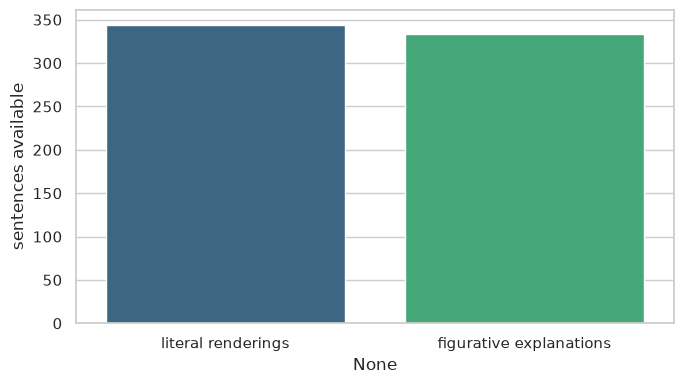

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = pd.Series({'literal renderings': len(df), 'figurative explanations': int((df.commentary.fillna('').str.len() > 15).sum())})
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis', legend=False, ax=ax)
ax.set_ylabel('sentences available')
plt.tight_layout(); plt.show()

**Figure 1: Number of literal renderings and figurative explanations available for the classification dataset.**

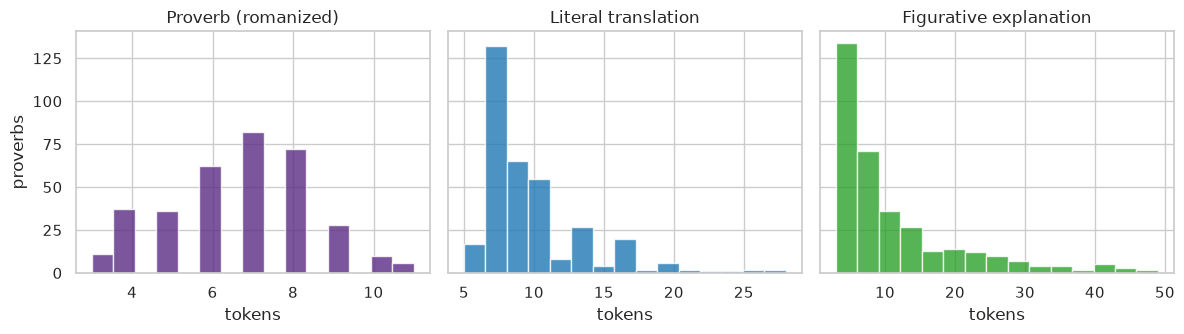

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, col, name, c in zip(axes, ['translit_tokens', 'literal_tokens', 'commentary_tokens'],
        ['Proverb (romanized)', 'Literal translation', 'Figurative explanation'],
        ['#5b2c83', '#1f77b4', '#2ca02c']):
    ax.hist(df[col], bins=15, color=c, alpha=0.8); ax.set_title(name); ax.set_xlabel('tokens')
axes[0].set_ylabel('proverbs')
plt.tight_layout(); plt.show()

**Figure 2: Token-length distributions for the proverb, its literal translation, and the explanation.**

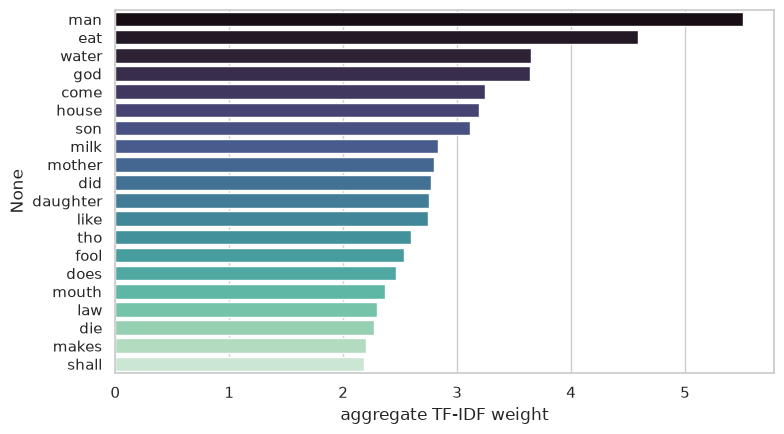

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(stop_words='english', max_features=4000)
X = vec.fit_transform(df.literal_en)
terms = np.array(vec.get_feature_names_out())
top = pd.Series(np.asarray(X.sum(axis=0)).ravel(), index=terms).nlargest(20)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette='mako', legend=False, ax=ax)
ax.set_xlabel('aggregate TF-IDF weight')
plt.tight_layout(); plt.show()

**Figure 3: Top TF-IDF terms in the literal translations.**

## 2. Literal vs figurative: lexical gap
If the intended meaning could be read off the surface words, the literal translation and its explanation would share vocabulary. To check this we measure the Jaccard token overlap between them.

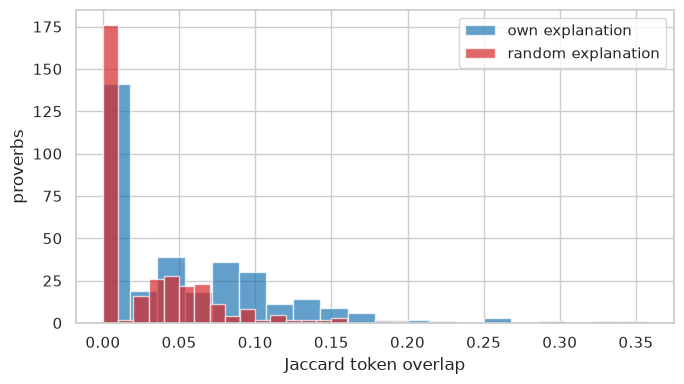

own: 0.051, random: 0.029


In [6]:
def jaccard(a, b):
    A = set(str(a).lower().split()); B = set(str(b).lower().split())
    return len(A & B) / len(A | B) if A | B else 0.0

has_comm = df[df.commentary.fillna('').str.len() > 15].reset_index(drop=True)
has_comm['overlap_own'] = [jaccard(r.literal_en, r.commentary) for r in has_comm.itertuples()]
rng = np.random.default_rng(42)
has_comm['overlap_random'] = [jaccard(r.literal_en, has_comm.commentary[rng.choice(len(has_comm))])
                              for r in has_comm.itertuples()]
metrics['jac_own'] = round(float(has_comm.overlap_own.mean()), 3)
metrics['jac_rand'] = round(float(has_comm.overlap_random.mean()), 3)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(has_comm.overlap_own, bins=20, alpha=0.7, label='own explanation', color='#1f77b4')
ax.hist(has_comm.overlap_random, bins=20, alpha=0.7, label='random explanation', color='#d62728')
ax.set_xlabel('Jaccard token overlap'); ax.set_ylabel('proverbs'); ax.legend()
plt.tight_layout(); plt.show()
print(f"own: {metrics['jac_own']}, random: {metrics['jac_rand']}")

**Figure 4: Jaccard overlap between each proverb's literal translation and its own explanation, compared with a random explanation.**

## 3. Model 1: literal vs figurative classification
Each proverb gives us two texts, its literal rendering and its figurative explanation. If a classifier can tell them apart, then figurative explanation has a recognizable style of its own. This is a small version of the team problem statement. Logistic regression over word TF-IDF, stratified 5-fold CV.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, confusion_matrix

texts = pd.concat([has_comm.literal_en, has_comm.commentary], ignore_index=True)
y = pd.Series(['literal'] * len(has_comm) + ['figurative'] * len(has_comm))
cv = StratifiedKFold(5, shuffle=True, random_state=42)
pipe = make_pipeline(TfidfVectorizer(sublinear_tf=True),
                     LogisticRegression(max_iter=2000, class_weight='balanced'))
acc = cross_val_score(pipe, texts, y, cv=cv).mean()
pred = cross_val_predict(pipe, texts, y, cv=cv)
metrics.update(clf_n=len(texts), clf_k=2, maj_acc=0.5, maj_f1=0.333,
    acc_en=round(float(acc), 3), f1_en=round(float(f1_score(y, pred, average='macro')), 3))
print(f"{len(texts)} sentences, 2 classes | chance = 0.500")
print(f"word TF-IDF + LogReg: acc={metrics['acc_en']}  macro-F1={metrics['f1_en']}")

668 sentences, 2 classes | chance = 0.500
word TF-IDF + LogReg: acc=0.726  macro-F1=0.724


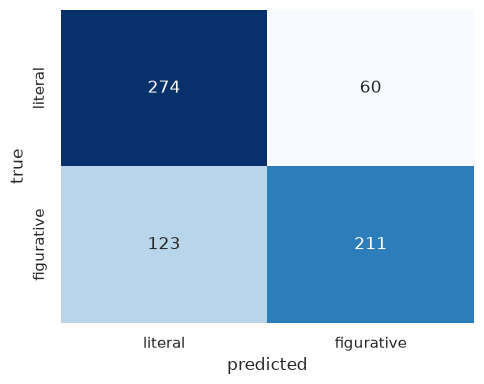

In [8]:
labels = ['literal', 'figurative']
cm = confusion_matrix(y, pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()

**Figure 5: Confusion matrix (cross-validated) for the literal vs figurative classifier.**

## 4. Model 2: literal to figurative retrieval
For every proverb we rank all explanations by cosine similarity to the query and check where the correct one lands. The query is the literal translation in the first condition and the romanized Hindi text in the second, which is the cross-lingual case.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieval_scores(sim):
    ranks = []
    for i in range(sim.shape[0]):
        order = np.argsort(-sim[i])
        ranks.append(int(np.where(order == i)[0][0]) + 1)
    ranks = np.array(ranks)
    return {'P@1': round(float((ranks == 1).mean()), 3),
            'P@5': round(float((ranks <= 5).mean()), 3),
            'MRR': round(float((1 / ranks).mean()), 3)}

vec_r = TfidfVectorizer(stop_words='english', sublinear_tf=True)
docs = vec_r.fit_transform(has_comm.commentary)
res = {}
res['TF-IDF (EN literal query)'] = retrieval_scores(cosine_similarity(vec_r.transform(has_comm.literal_en), docs))
res['TF-IDF (source-language query)'] = retrieval_scores(cosine_similarity(vec_r.transform(has_comm.proverb_translit), docs))
n = len(has_comm)
res['Random baseline'] = {'P@1': round(1/n, 3), 'P@5': round(5/n, 3),
                          'MRR': round(float(np.mean([1/r for r in range(1, n+1)])), 3)}
metrics['retrieval'] = res
metrics['n_retr'] = n
pd.DataFrame(res).T

,P@1,P@5,MRR
TF-IDF (EN literal query),0.081,0.138,0.114
TF-IDF (source-language query),0.024,0.045,0.044
Random baseline,0.003,0.015,0.019


In [10]:
# Multilingual transformer condition (LaBSE). Run on Colab if
# sentence-transformers is not installed locally.
try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer('sentence-transformers/LaBSE')
    q_en = model.encode(list(has_comm.literal_en), show_progress_bar=False)
    q_src = model.encode(list(has_comm.proverb_translit), show_progress_bar=False)
    d_c = model.encode(list(has_comm.commentary), show_progress_bar=False)
    res['LaBSE (EN literal query)'] = retrieval_scores(cosine_similarity(q_en, d_c))
    res['LaBSE (source-language query)'] = retrieval_scores(cosine_similarity(q_src, d_c))
    print(pd.DataFrame(res).T)
except ImportError:
    print('sentence-transformers not installed, run the LaBSE condition on Colab.')

/home/ibu/Documents/collegework/sem7/ccnlp/cca1/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10244.95it/s]

                                  P@1    P@5    MRR
TF-IDF (EN literal query)       0.081  0.138  0.114
TF-IDF (source-language query)  0.024  0.045  0.044
Random baseline                 0.003  0.015  0.019
LaBSE (EN literal query)        0.066  0.159  0.119
LaBSE (source-language query)   0.009  0.027  0.031


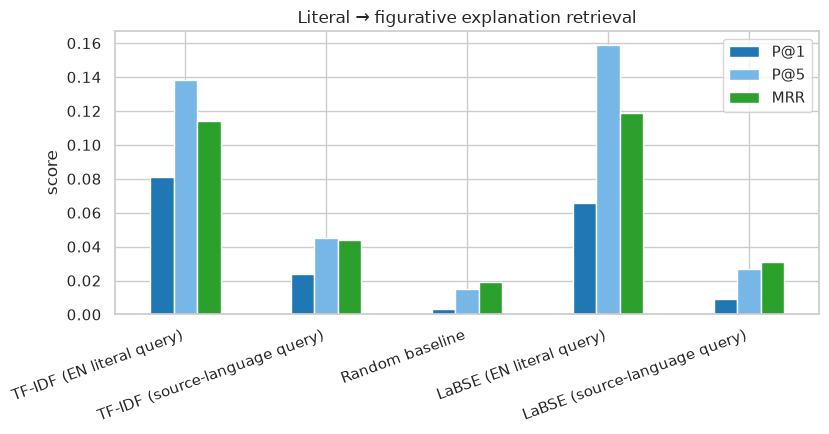

In [11]:
rdf = pd.DataFrame(res).T
fig, ax = plt.subplots(figsize=(8.5, 4.5))
rdf[['P@1', 'P@5', 'MRR']].plot.bar(ax=ax, color=['#1f77b4', '#76b7e8', '#2ca02c'])
ax.set_ylabel('score'); ax.set_title('Literal → figurative explanation retrieval')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

**Figure 6: Retrieval scores for TF-IDF and LaBSE, with English-literal queries and with source-language queries.**

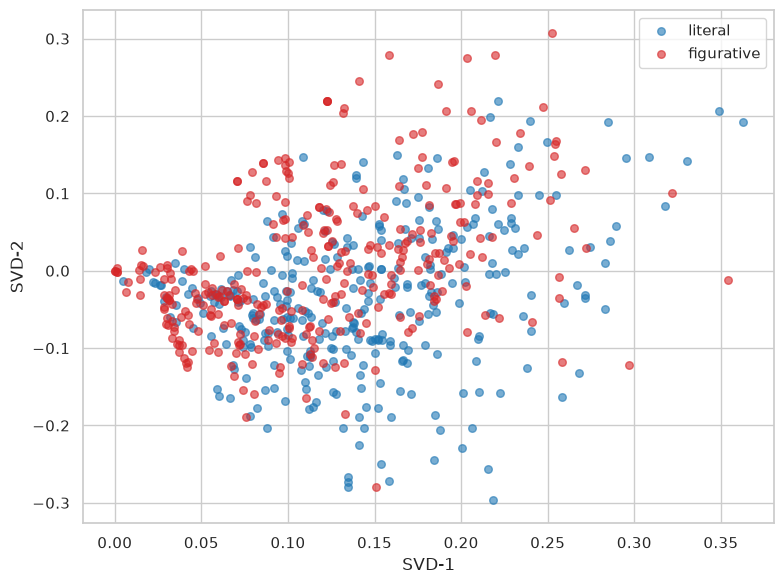

In [12]:
from sklearn.decomposition import TruncatedSVD
X_all = TfidfVectorizer(sublinear_tf=True).fit_transform(texts)
xy = TruncatedSVD(2, random_state=42).fit_transform(X_all)
fig, ax = plt.subplots(figsize=(8, 6))
for lab, c in [('literal', '#1f77b4'), ('figurative', '#d62728')]:
    m = (y == lab).values
    ax.scatter(xy[m, 0], xy[m, 1], label=lab, alpha=0.6, s=30, color=c)
ax.legend(); ax.set_xlabel('SVD-1'); ax.set_ylabel('SVD-2')
plt.tight_layout(); plt.show()

**Figure 7: 2-D SVD projection of literal renderings and figurative explanations. The two groups sit in visibly different regions.**

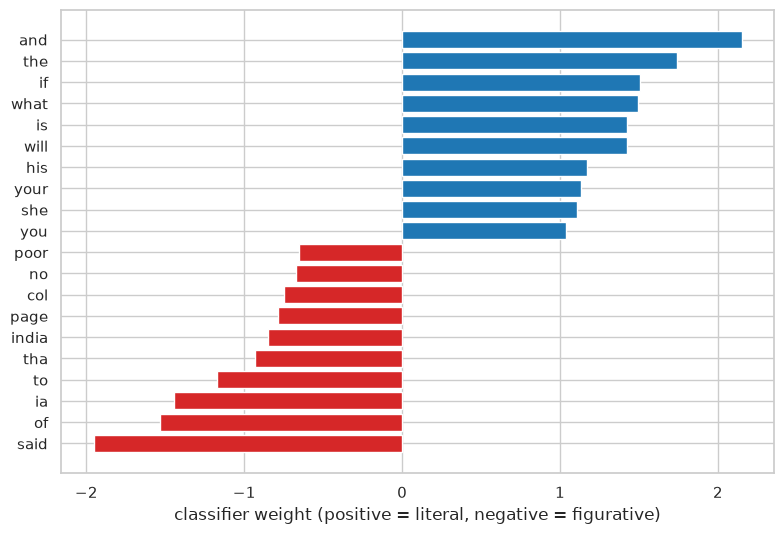

In [13]:
pipe.fit(texts, y)
vec_f = pipe.named_steps['tfidfvectorizer']
clf_f = pipe.named_steps['logisticregression']
coefs = clf_f.coef_[0]
names = np.array(vec_f.get_feature_names_out())
pos_class = clf_f.classes_[1]
top = np.concatenate([np.argsort(coefs)[:10], np.argsort(coefs)[-10:]])
colors = ['#d62728' if coefs[i] < 0 else '#1f77b4' for i in top]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(names[top], coefs[top], color=colors)
ax.set_xlabel(f'classifier weight (positive = {pos_class}, negative = {clf_f.classes_[0]})')
plt.tight_layout()
plt.show()

**Figure 8: The 10 strongest classifier weights for each class. The literal side is carried by ordinary sentence words, while the figurative side leans on 'said' and on dictionary artifacts (page, col) that leaked through the OCR, so part of the classifier's accuracy comes from formatting rather than meaning.**

In [14]:
import os
os.makedirs('report', exist_ok=True)
json.dump(metrics, open('report/PanelB_16_metrics_hindi.json', 'w'), indent=1)
print('metrics saved:', json.dumps(metrics)[:300])

metrics saved: {"n": 344, "n_comm": 334, "tok_src": 2301, "tok_en": 3454, "tok_comm": 3935, "voc_src": 1731, "voc_en": 1446, "len_src": 6.7, "len_en": 10.0, "len_comm": 11.4, "jac_own": 0.051, "jac_rand": 0.029, "clf_n": 668, "clf_k": 2, "maj_acc": 0.5, "maj_f1": 0.333, "acc_en": 0.726, "f1_en": 0.724, "retrieval"


## 5. Discussion (Ibrahim Ansari)
The classifier could tell literal renderings apart from figurative glosses with accuracy 0.726 and macro-F1 0.724 over 668 sentences, where chance is 0.500. So the two kinds of text do differ in wording, and by enough for a simple model to pick up. Reading through the corpus suggests why: glosses tend to use stock phrases like 'said of' or 'said to', while literal renderings describe concrete scenes. The classifier weights add a caveat, though. Some of the separation comes from dictionary artifacts, such as page and column references that leaked into the glosses through OCR, and not from meaning. At the same time, the overlap measurement (Jaccard 0.051 with a proverb's own gloss, 0.029 with a random one) shows the two layers share almost no actual vocabulary. That limits what lexical retrieval can do: P@1 is 0.081 for English-literal queries and 0.024 for romanized-Hindustani queries, with a random baseline of 0.003. Of the three tracks this one has the weakest cross-lingual retrieval. The LaBSE condition did not improve it: P@1 0.066 with English queries and 0.009 with romanized queries. As in the other tracks, the model expects native script and the 1886 romanization is foreign to it. The main limitations are heavy OCR noise in the 1886 two-column print, romanization instead of Devanagari, and glosses that sometimes quote an equivalent English idiom instead of describing the meaning.

## 6. Conclusion
A 344-proverb Hindustani corpus was built from Fallon (1886). The literal and figurative layers can be told apart by a classifier (accuracy 0.726, chance 0.500) even though they share almost no vocabulary (0.051 vs 0.029 Jaccard). Retrieval of the correct gloss reaches P@1 0.081 with English queries and only 0.024 across the language boundary. LaBSE on the romanized text did not do better, so converting the corpus to Devanagari is the next step.

## References (APA)
- Fallon, S. W. (1886). *A dictionary of Hindustani proverbs.* Banaras: Medical Hall Press. https://archive.org/details/in.ernet.dli.2015.42145
- Feng, F., Yang, Y., Cer, D., Arivazhagan, N., & Wang, W. (2022). Language-agnostic BERT sentence embedding. *Proceedings of ACL 2022*, 878–891.
- Khanuja, S., et al. (2021). MuRIL: Multilingual representations for Indian languages. *arXiv:2103.10730*.
- Kakwani, D., et al. (2020). IndicNLPSuite: Monolingual corpora, evaluation benchmarks and pre-trained multilingual language models for Indian languages. *Findings of EMNLP 2020*, 4948–4961.